In [1]:
import sys
sys.path.append("..")

import jax, os, corner
import jax.numpy as jnp
from jax import grad, config
import matplotlib.pyplot as plt
import numpy as np
config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)
from functools import partial
from models.priors import Mc_eta_uniform_masses_draw
# from models.gw150914 import gwfast_LVGW150914

from models.gw150914_v2 import gwfast_LVGW150914
from models.gwfast.waveforms import TaylorF2_RestrictedPN, IMRPhenomD

from src.pampel import ula_sampler_full_jax_jit
from src.helper import rejection_sampling

print(jax.devices())

[cuda(id=0)]


In [2]:
# Initialize model
model = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=100)

Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/aLIGO_O4_high_asd.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/aLIGO_O4_high_asd.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/AdV_asd.txt 
fmin:  10.0
fmax:  560.0
df_standard:  5.5
nbins:  100
SNR at true values: 91.57


In [ ]:
# Confirmation that the potential and the gradient are in agreement!
x = model._newDrawFromPrior(1)
test1 = jax.jacobian(model.potential)(x)
test2 = model.gradient_potential(x)
print(test1)
print(test2)

In [3]:
# Setup and run sampler
n_iter = 50000
n_particles = 200
# eps = 1e-6

eps = jnp.ones(11)
eps = eps.at[model.bounded_coordinates].set(1e-6)
eps = eps.at[model.periodic_coordinates].set(1e-6)

# Birth death
stride = n_iter + 1 
rate = 1e-6 
bandwidth = jnp.ones(model.DoF) * 0.01
bandwidth = bandwidth.at[jnp.array([4, 6, 8])].set(jnp.ones(3) * 0.01)

# Initial draw from prior
X0 = model._newDrawFromPrior(n_particles)

key = jax.random.PRNGKey(0)

sam = ula_sampler_full_jax_jit(key, model.potential, model.gradient_potential, n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, bandwidth, model.bounded_coordinates, model.periodic_coordinates)

136949 samples obtained from rejection sampling


In [ ]:
sam = ula_sampler_full_jax_jit(key, model.potential, model.gradient_potential, n_iter, eps, sam[-1], model.lower_bound, model.upper_bound, 100, rate, bandwidth, model.bounded_coordinates, model.periodic_coordinates)

137120 samples obtained from rejection sampling


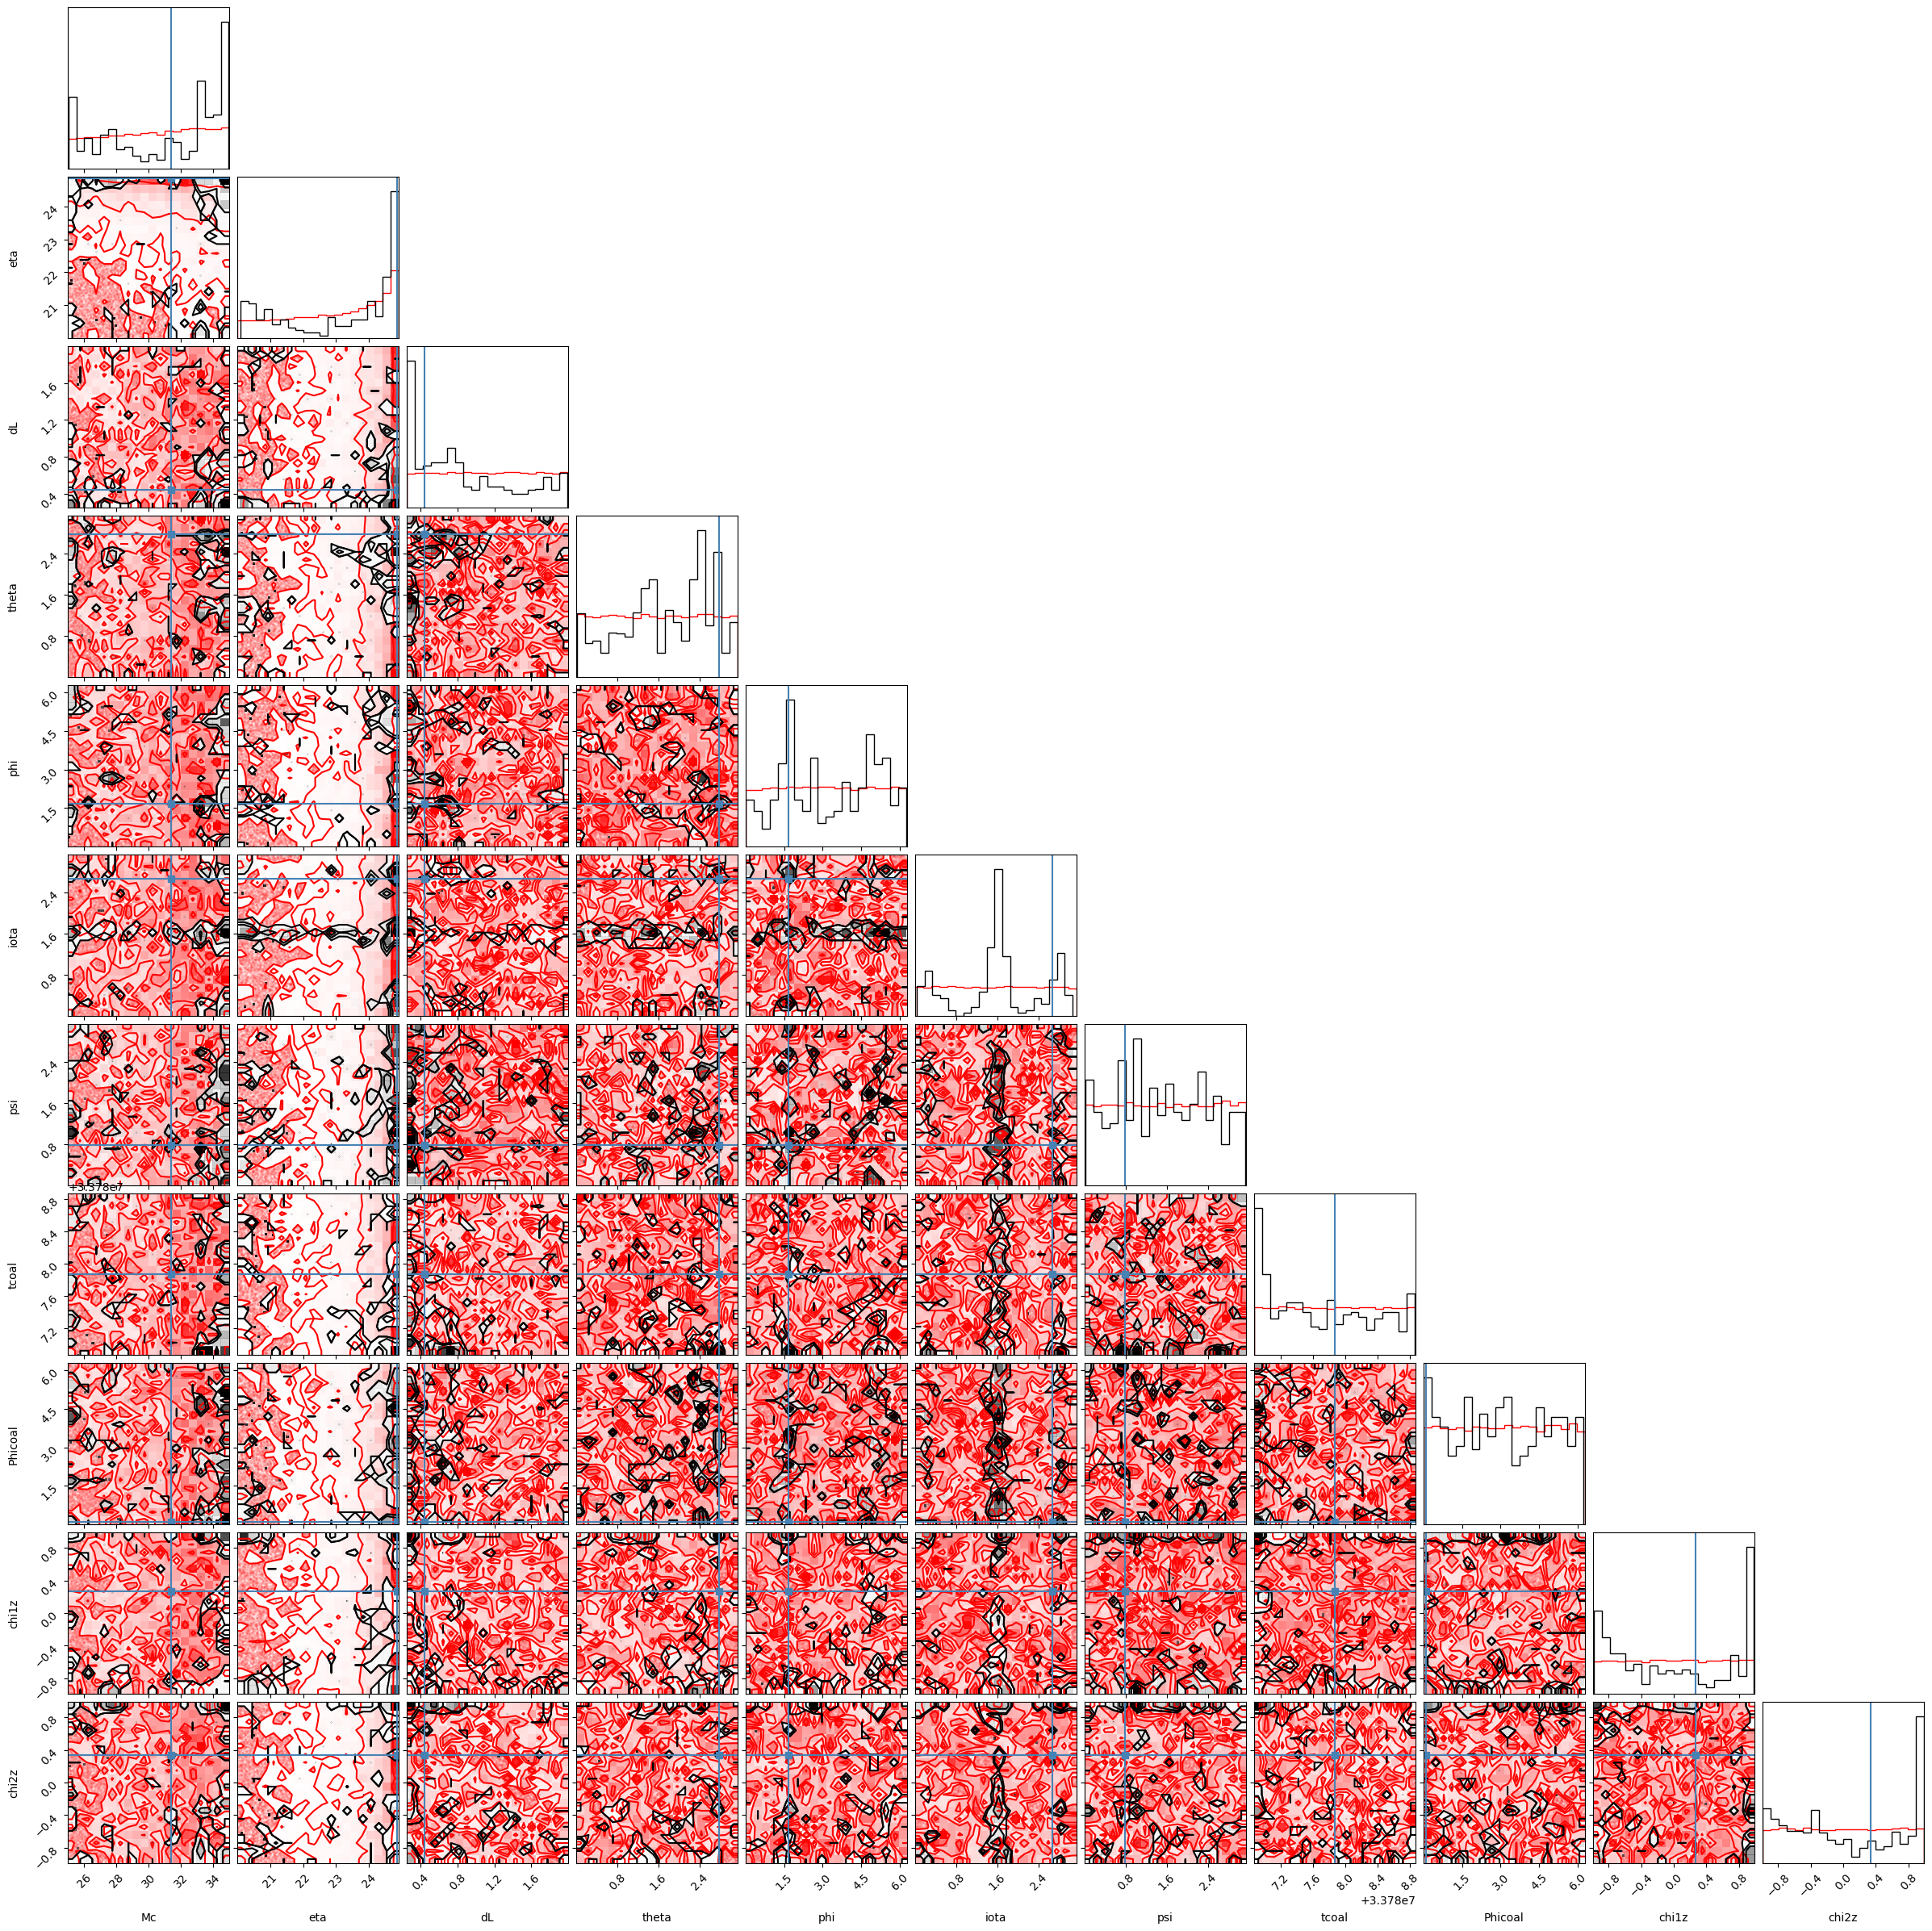

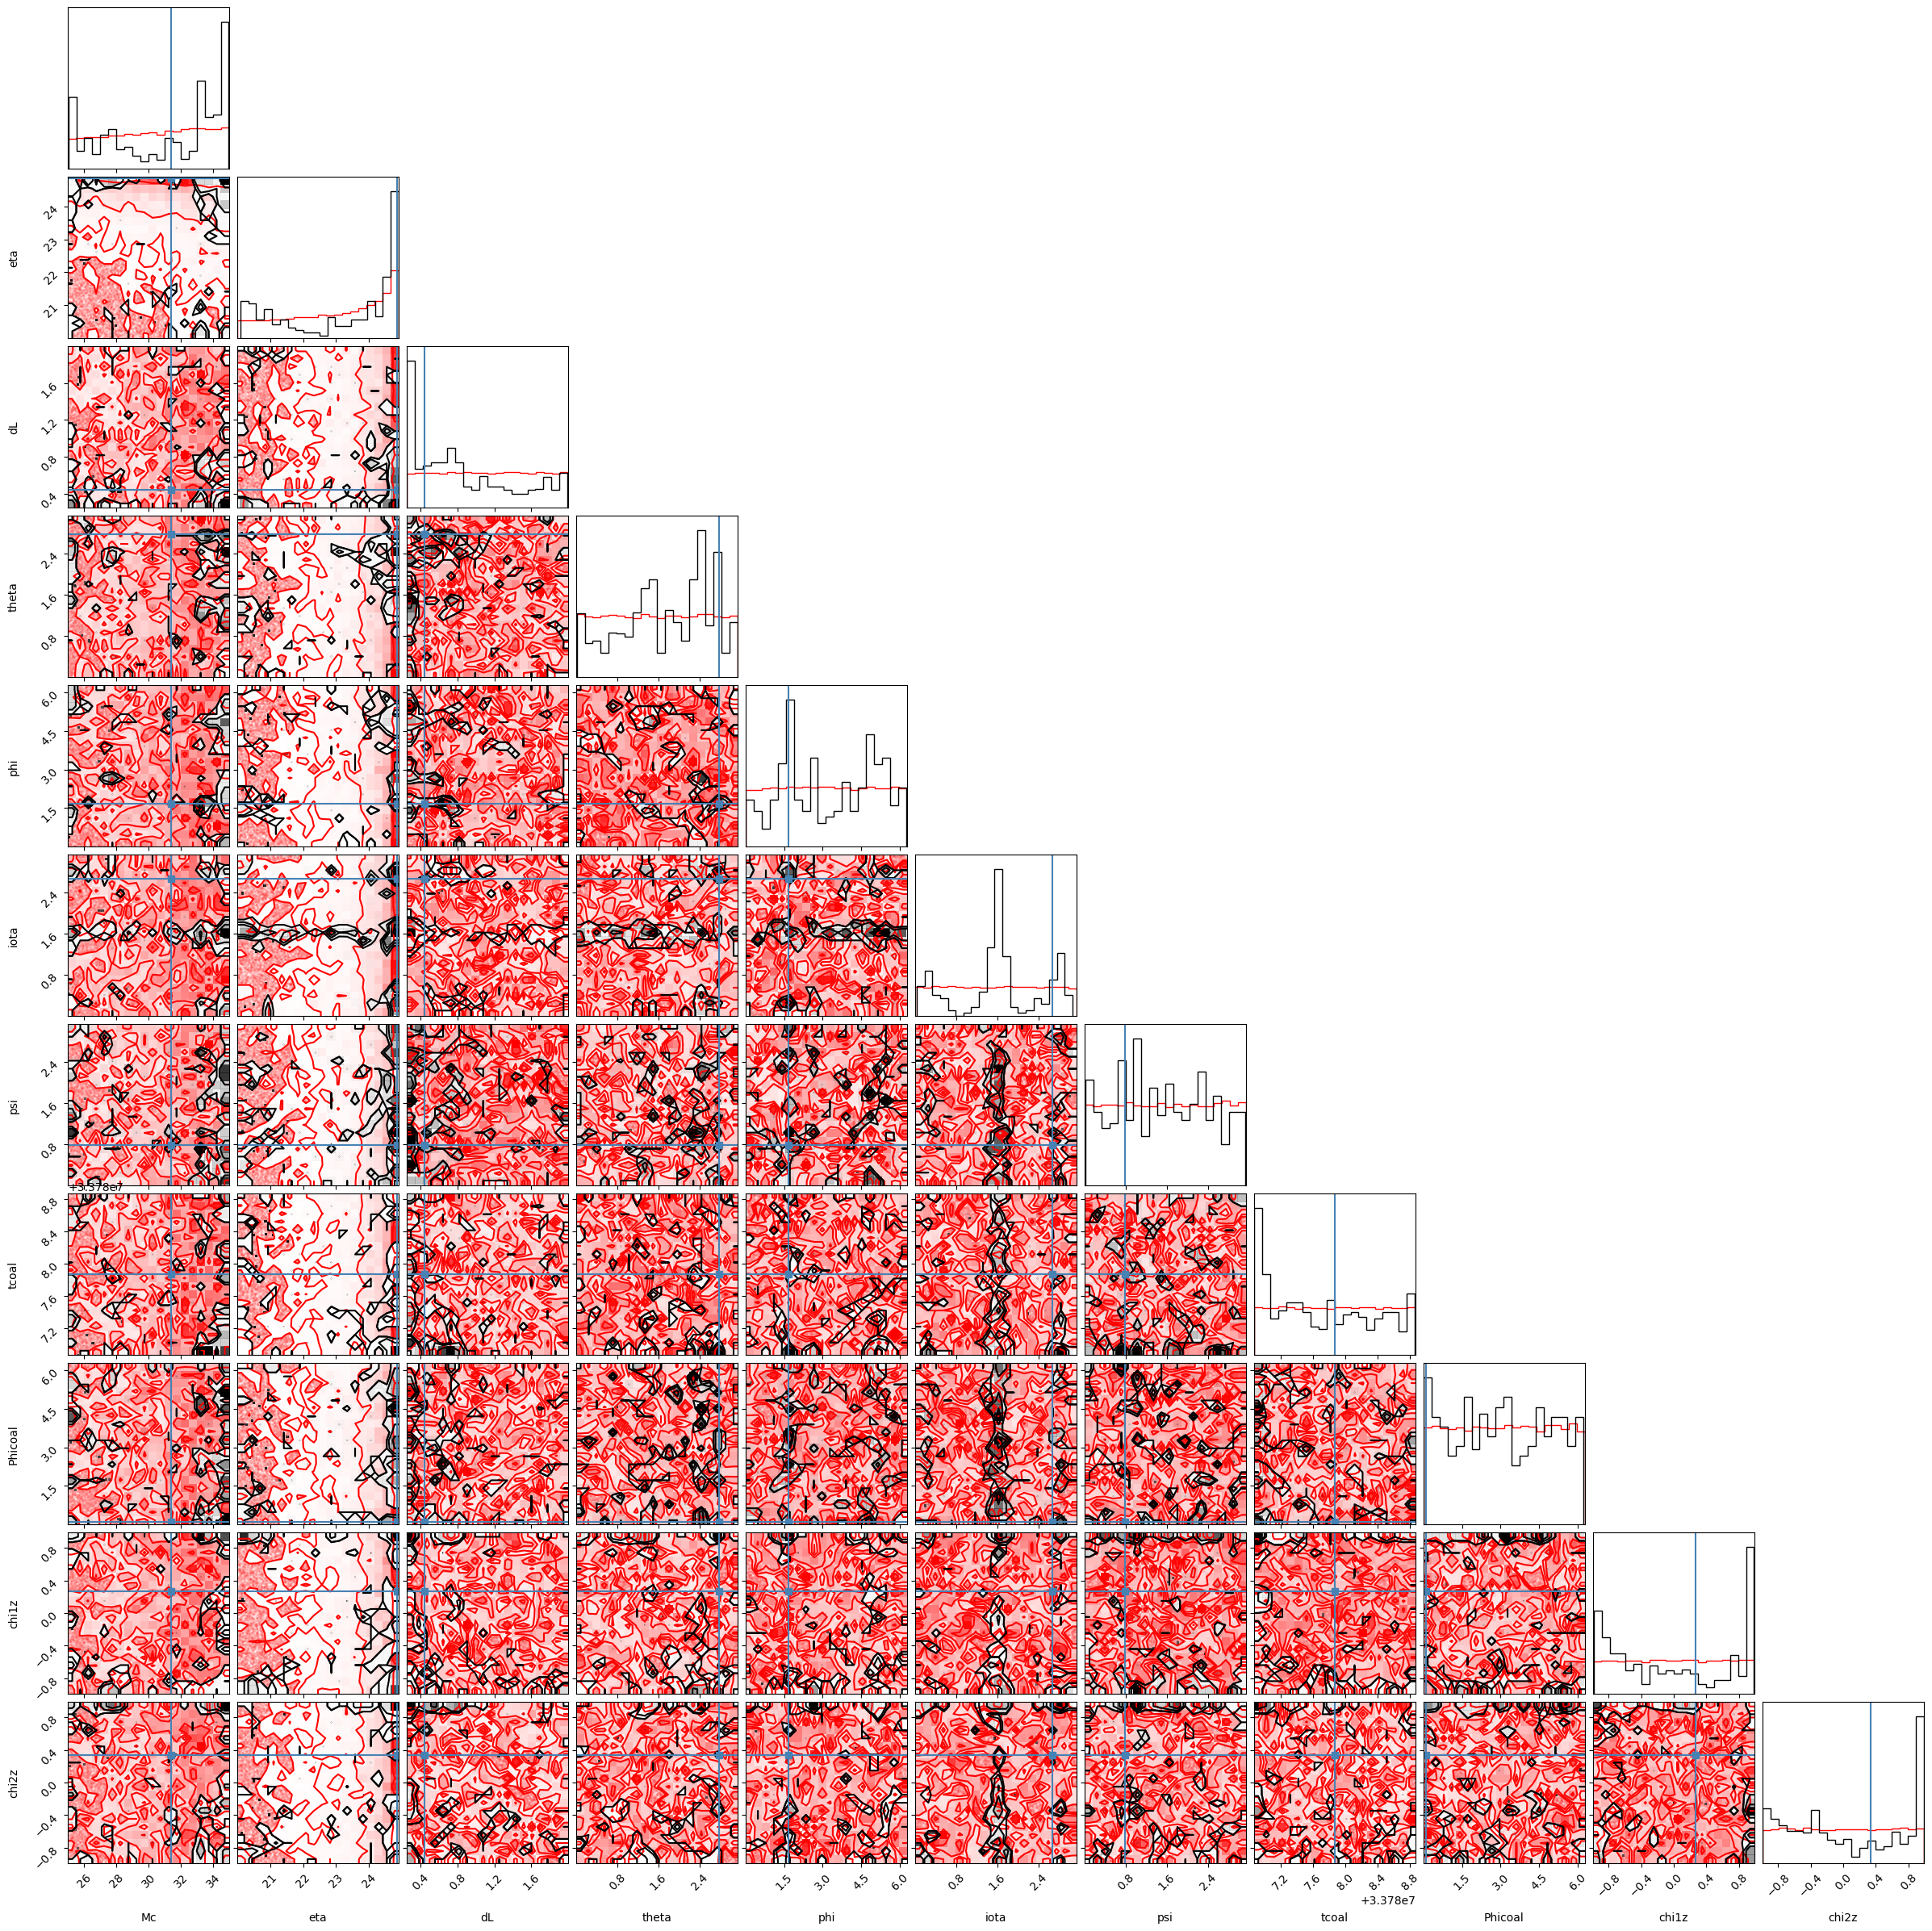

In [5]:
reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], 11)))
fig = corner.corner(np.array(model._newDrawFromPrior(50000)), color='r', hist_kwargs={'density':True})
corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order, truths=model.true_params, fig=fig)

In [ ]:
# NEW VERSION

def plot_cross_section(index1, index2, func, n_grid, injection, a, b, labels):
    assert index1 < index2

    N = n_grid ** 2
    d = len(a)

    x = np.linspace(a[index1], b[index1], n_grid)
    y = np.linspace(a[index2], b[index2], n_grid)

    # Get grid x and y positions
    X, Y = np.meshgrid(x, y)

    # Get heat value on (X,Y)
    particle_grid = np.zeros((N, d))
    for i in range(d): # Fix all other parameters
        if i == index1:
            particle_grid[:, i] = X.flatten()
        elif i == index2:
            particle_grid[:, i] = Y.flatten()
        else:
            particle_grid[:, i] = np.ones(N) * injection[i]

    # Get Z values for heat map
    Z = func(particle_grid).reshape(n_grid,n_grid)

    # Plot settings
    fig, ax = plt.subplots(figsize = (5, 5))
    cp = ax.contourf(X, Y, Z)
    ax.scatter(injection[index1], injection[index2], s=0.1, marker='x', c='r')
    ax.axis('equal')
    plt.colorbar(cp)
    ax.set_xlabel(labels[index1])
    ax.set_ylabel(labels[index2])
    ax.set_title('Energy cross section')
    filename = str(index1) + str(index2) + '.png'
    path = os.path.join('marginals', filename)

In [ ]:
posterior     = jax.jit(lambda X: jnp.exp(-1 * model.potential(X)))
neg_potential = jax.jit(lambda X: -1 * model.potential(X))

for i in range(model.DoF):
    for j in range(i+1, model.DoF):
        print('Getting cross section for %i, %i' % (i,j))
        # plot_cross_section(i, j, posterior, 200)
        plot_cross_section(i, j, neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)